## Project 2  - NLP

In [1]:
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
import seaborn as sns 
import re





   label                                              title  \
0      1  As U.S. budget fight looms, Republicans flip t...   
1      1  U.S. military to accept transgender recruits o...   
2      1  Senior U.S. Republican senator: 'Let Mr. Muell...   
3      1  FBI Russia probe helped by Australian diplomat...   
4      1  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   
2  December 31, 2017   
3  December 30, 2017   
4  December 29, 2017   
3859
3965
count    39942.000000
mean      2384.637875
st

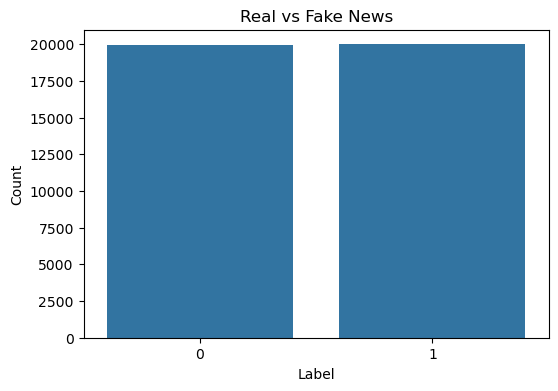

In [2]:
# Milesotne 1 - load and explore the data

import pandas as pd

df = pd.read_csv("dataset/data.csv")
#print(df.shape)
print(df.head(5))
#print(df['label'].value_counts())          # check class balance
#print(df.isnull().sum())                   # check missing values
#print(df['subject'].value_counts())        # sanity check on categories
print(df['title'].duplicated().sum())          # check for title duplicates
print(df['text'].duplicated().sum())          # check for text duplicates

# character length
df['text_char_len'] = df['text'].fillna('').apply(len)

# word count (simple split-based)
df['text_word_len'] = df['text'].fillna('').apply(lambda x: len(x.split()))

print(df['text_char_len'].describe())
print(df['text_word_len'].describe())

plt.figure(figsize=(6,4)) 
sns.countplot(data=df, x="label") 
plt.title("Real vs Fake News") 
plt.xlabel("Label") 
plt.ylabel("Count") 
plt.show()


#keep in mind duplicates (maybe same artical in different subjects)> maybe we remove them? 


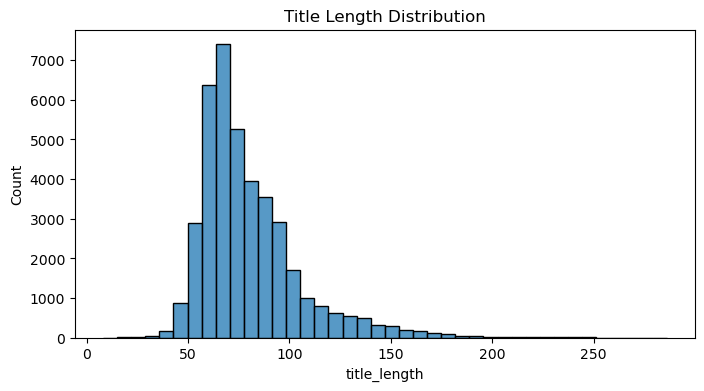

In [3]:
df["title_length"] = df["title"].str.len() 
plt.figure(figsize=(8,4)) 
sns.histplot(df["title_length"], bins=40) 
plt.title("Title Length Distribution") 
plt.show()

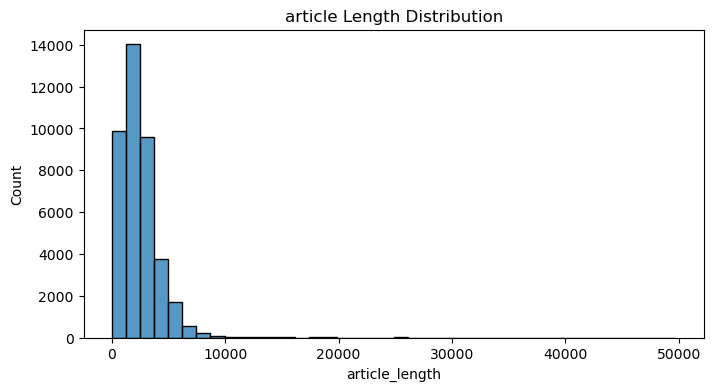

In [4]:
df["article_length"] = df["text"].str.len() 
plt.figure(figsize=(8,4)) 
sns.histplot(df["article_length"], bins=40) 
plt.title("article Length Distribution") 
plt.show()

In [5]:
'''
plt.figure(figsize=(10,6)) 
sns.countplot( data=df, y="title", hue="label", order=df["title"].value_counts().index ) 
plt.title("News title by Label") 
plt.xlabel("Count") 
plt.ylabel("Subject") 
plt.legend(title="Label", labels=["Fake", "Real"]) 
plt.show()
'''

'\nplt.figure(figsize=(10,6)) \nsns.countplot( data=df, y="title", hue="label", order=df["title"].value_counts().index ) \nplt.title("News title by Label") \nplt.xlabel("Count") \nplt.ylabel("Subject") \nplt.legend(title="Label", labels=["Fake", "Real"]) \nplt.show()\n'

In [6]:
# Diagnostic on the baseline model showed 99% accuracy driven almost entirely
#   - real articles: Reuters wire-service dateline, e.g. "WASHINGTON (Reuters) - ..."
#   - fake articles: scraped website boilerplate, e.g. "Featured image", "Getty Images"
# The model was learning "which site formatted this" instead of "is this fake news" - this must be removed BEFORE dedup/EDA/split, or every downstream
# step (and the leaderboard-facing predictions.csv) inherits the leak.
def strip_source_artifacts(text):
    # remove Reuters-style dateline: "WASHINGTON (Reuters) - "
    text = re.sub(r'^.*?\(Reuters\)\s*-\s*', '', text)
    # remove "Featured image" / "Getty Images" style captions
    text = re.sub(r'featured image.*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'getty images?', '', text, flags=re.IGNORECASE)
    return text
 
df['text'] = df['text'].apply(strip_source_artifacts)

In [7]:
#drop extra columns

df = df.drop(columns=['text_char_len', 'text_word_len', 'title_length', 'article_length'])

In [8]:
# REMOVE DUPLICATES

# how many are FULL duplicates (title + text + label all identical)?
full_dupes = df.duplicated(subset=['title', 'text'], keep=False)
print("Full duplicate rows:", full_dupes.sum())

# are duplicated texts ever labeled differently? (contradiction = data quality issue)
dupe_text_groups = df[df['text'].duplicated(keep=False)].groupby('text')['label'].nunique()
conflicting = dupe_text_groups[dupe_text_groups > 1]
print("Texts with conflicting labels:", len(conflicting))

# drop full duplicates (keep first occurrence)
df = df.drop_duplicates(subset=['title', 'text'], keep='first')
print(df.shape)

# drop rows with conflicting labels entirely (can't trust either)
conflicting_texts = conflicting.index
df = df[~df['text'].isin(conflicting_texts)]
print(df.shape)



Full duplicate rows: 6887
Texts with conflicting labels: 1
(36428, 5)
(35990, 5)


In [9]:
#we want to drop columns > date & subject
df = df.drop(columns=['date', 'subject'])

print(df.shape)



(35990, 3)


In [10]:
#drop Labels to avoid data leakage

X = df.drop(columns=["label"])
y = df["label"]

print(X.head(5))

                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text  
0  The head of a conservative Republican faction ...  
1  Transgender people will be allowed for the fir...  
2  The special counsel investigation of links bet...  
3  Trump campaign adviser George Papadopoulos tol...  
4  President Donald Trump called on the U.S. Post...  


In [11]:
#Milestone 2 — Train/test split (before any preprocessing)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, y_train.shape)




(28792, 2) (28792,)


In [12]:
#Milestone 3 — Text cleaning
import re


def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)            # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()          # collapse whitespace
    return text


X_train = X_train.copy()
X_test = X_test.copy()

X_train['title_clean'] = X_train['title'].apply(clean_text)
X_train['text_clean'] = X_train['text'].apply(clean_text)
X_test['title_clean'] = X_test['title'].apply(clean_text)
X_test['text_clean'] = X_test['text'].apply(clean_text)


print(X_train.head(5))



                                                   title  \
19281  China's ruling party expels anti-graft, ex-ins...   
32080  DIAMOND AND SILK Go Off On Michelle Obama For ...   
28402   WATCH: Female Cop Halts Sex Offender’s Violen...   
3957    Florida LGBT rights push reflects changing times   
15290  SpaceX to launch Turkish satellites, minister ...   

                                                    text  \
19281  China s ruling Communist Party has expelled th...   
32080  .@DiamondandSilk watched Oprah s interview wit...   
28402  Earlier in January, 31-year-old Michael Cox wa...   
3957   A Republican, a Democrat and a lobbyist for le...   
15290  Turkey s Turksat 5A and 5B satellites will be ...   

                                             title_clean  \
19281  china s ruling party expels anti graft ex insu...   
32080  diamond and silk go off on michelle obama for ...   
28402  watch female cop halts sex offender s violent ...   
3957    florida lgbt rights push refle

In [13]:
# Milestone 4 — Feature extraction (separate TF-IDF for title and text)
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=20000,
    ngram_range=(1, 2)
)

title_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2))
text_vectorizer = TfidfVectorizer(stop_words='english', max_features=20000, ngram_range=(1, 2))


X_train_title = title_vectorizer.fit_transform(X_train['title_clean'])
X_train_text = text_vectorizer.fit_transform(X_train['text_clean'])
X_test_title = title_vectorizer.transform(X_test['title_clean'])
X_test_text = text_vectorizer.transform(X_test['text_clean'])

X_train_combined = hstack([X_train_title, X_train_text])
X_test_combined = hstack([X_test_title, X_test_text])


print("Feature matrix shapes:", X_train_combined.shape, X_test_combined.shape)

Feature matrix shapes: (28792, 25000) (7198, 25000)


In [14]:
# tidy up: title_clean/text_clean already vectorized, no longer needed in the dataframes
X_train = X_train.drop(columns=['title_clean', 'text_clean'])
X_test = X_test.drop(columns=['title_clean', 'text_clean'])

In [15]:
# Milestone 5 — Baseline model
# ---------------------------------------------------------------------------
baseline_model = LogisticRegression()
baseline_model.fit(X_train_combined, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
#Milestone 6 — Evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = baseline_model.predict(X_test_combined)
 
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))


# quick title-only / text-only comparison
lr_title = LogisticRegression().fit(X_train_title, y_train)
print("Title only accuracy:", accuracy_score(y_test, lr_title.predict(X_test_title)))
 
lr_text = LogisticRegression().fit(X_train_text, y_train)
print("Text only accuracy:", accuracy_score(y_test, lr_text.predict(X_test_text)))



Accuracy: 0.9841622672964713
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3240
           1       0.98      0.99      0.99      3958

    accuracy                           0.98      7198
   macro avg       0.98      0.98      0.98      7198
weighted avg       0.98      0.98      0.98      7198

[[3161   79]
 [  35 3923]]
Title only accuracy: 0.9398444012225619
Text only accuracy: 0.9774937482634065


In [17]:
# --- Diagnostic: check for source/dateline artifact ---
print(df['text'].str.contains('Reuters').groupby(df['label']).mean())

label
0    0.011171
1    0.229634
Name: text, dtype: float64


In [18]:
# --- Diagnostic: check for leaked duplicates across split ---
overlap = set(X_train['text']).intersection(set(X_test['text']))
print(len(overlap))

3


In [19]:
# --- Diagnostic: inspect top model coefficients ---
import numpy as np

feature_names = text_vectorizer.get_feature_names_out()
coefs = baseline_model.coef_[0][-len(feature_names):]

top_positive = np.argsort(coefs)[-15:]
top_negative = np.argsort(coefs)[:15]

print("Top words pushing toward label 1:", [feature_names[i] for i in top_positive])
print("Top words pushing toward label 0:", [feature_names[i] for i in top_negative])

Top words pushing toward label 1: ['minister', 'democratic', 'president barack', 'said statement', 'nov', 'presidential', 'monday', 'friday', 'thursday', 'tuesday', 'republican', 'wednesday', 'president donald', 'reuters', 'said']
Top words pushing toward label 0: ['just', 'gop', 'read', 'like', 'mr', 'president obama', 'fact', 'america', 'com', 'president trump', 'doesn', 'hillary', 'didn', 'know', 'isn']


In [20]:
# how often does "reuters" appear ANYWHERE in the text, not just as a leading dateline?
print(df['text'].str.contains('reuters', case=False).groupby(df['label']).mean())

# check the .com artifact too
print(df['text'].str.contains(r'\.com', case=False, regex=True).groupby(df['label']).mean())

label
0    0.011480
1    0.230493
Name: text, dtype: float64
label
0    0.220960
1    0.008389
Name: text, dtype: float64
